In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Conv2d

## Форма выходных данных для одно и многоканальных картинок

In [4]:
images = torch.empty((10, 1, 16, 16)) # 10 single channel images
conv = nn.Conv2d(1, 4, kernel_size=3, padding=1)
conv(images).shape

torch.Size([10, 4, 16, 16])

In [5]:
images = torch.empty((10, 3, 16, 16)) # 10 three-channel images
conv = nn.Conv2d(3, 4, kernel_size=3, padding=1)
conv(images).shape

torch.Size([10, 4, 16, 16])

## Как работает Conv2d на многоканальном image?

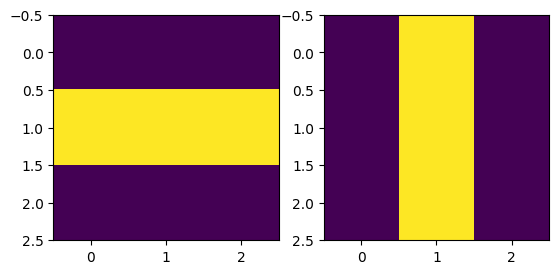

In [36]:
image = torch.zeros(2, 3, 3) # two-channel 3x3 image
image[0,1,:] = 1
image[1,:,1] = 1
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(image[0]);
ax2.imshow(image[1]);

In [48]:
images = image.reshape(1, *image.shape)
conv = nn.Conv2d(image.shape[0], 3, kernel_size=3, padding=0, bias=False)

In [39]:
v_list = []

for conv_layer_ind in range(conv.weight.shape[0]):
    v = 0
    
    for channel_ind in range(image.shape[0]):
        v += image[channel_ind].ravel() @ conv.weight[conv_layer_ind,channel_ind].ravel()

    v_list.append(v.item())

v_list = np.array(v_list)

In [40]:
a = conv(images).detach().numpy().ravel()
b = v_list
print(a, b)
assert np.all(np.isclose(a, b))

[ 0.10704701 -0.18643337  0.3280459 ] [ 0.10704702 -0.18643337  0.3280459 ]


- каждый из 3-х свёрточных слоев работает независимо от других
- каждый свёрточный слой содержит содержит 2 подслоя для кажого из каналов картинки
- подслои суммируются при свёртке

## Группы в Сonv2d

In [50]:
feature_maps = torch.zeros(32, 100, 100) # 32 feature maps 100x100
conv = nn.Conv2d(feature_maps.shape[0], 64, kernel_size=3, groups=1)
# Получаем 64 ядра, каждый из которых соединён с каждым им 32 feature_maps
conv.weight.shape

torch.Size([64, 32, 3, 3])

In [51]:
feature_maps = torch.zeros(32, 100, 100) # 32 feature maps 100x100
conv = nn.Conv2d(feature_maps.shape[0], 64, kernel_size=3, groups=2)
# Получаем 64 ядра, каждый из которых соединён с каким-то 16-ью из feature_maps
conv.weight.shape

torch.Size([64, 16, 3, 3])

In [52]:
feature_maps = torch.zeros(32, 100, 100) # 32 feature maps 100x100
conv = nn.Conv2d(feature_maps.shape[0], 64, kernel_size=3, groups=16)
# Получаем 64 ядра, каждый из которых соединён с каким-то 2-мя из feature_maps
conv.weight.shape

torch.Size([64, 2, 3, 3])

# AvgPool3d

## 3d boxcar filter

In [141]:
feature_maps = torch.rand(1, 3, 4, 4) # batch, feature, width, height
feature_maps

tensor([[[[0.4895, 0.1752, 0.3100, 0.3907],
          [0.4360, 0.4364, 0.3863, 0.2884],
          [0.4739, 0.9760, 0.2971, 0.4636],
          [0.8331, 0.2547, 0.8888, 0.6175]],

         [[0.2366, 0.9734, 0.9858, 0.4491],
          [0.7990, 0.1353, 0.7849, 0.8072],
          [0.9540, 0.8895, 0.2471, 0.2783],
          [0.0866, 0.8212, 0.5420, 0.6066]],

         [[0.1589, 0.3468, 0.8394, 0.9685],
          [0.4554, 0.4569, 0.9059, 0.2682],
          [0.8319, 0.0734, 0.0322, 0.9504],
          [0.1271, 0.1230, 0.7562, 0.4807]]]])

In [140]:
boxcar_width = 3
padding = boxcar_width // 2 
pool = nn.AvgPool3d(kernel_size=boxcar_width, stride=1, padding=padding, count_include_pad=False)

In [143]:
v = torch.zeros_like(feature_maps)
y = torch.zeros_like(feature_maps)

for b in range(feature_maps.shape[0]):
    for i in range(feature_maps.shape[1]):
        for j in range(feature_maps.shape[2]):
            for k in range(feature_maps.shape[3]):
                s = []

                for di in range(-padding, padding+1):
                    for dj in range(-padding, padding+1):
                        for dk in range(-padding, padding+1):
                            i2 = i + di
                            j2 = j + dj
                            k2 = k + dk
                            
                            if i2 < 0 or j2 < 0 or k2 < 0 or i2 >= feature_maps.shape[1] or j2 >= feature_maps.shape[2] or k2 >= feature_maps.shape[3]:
                                # print(f'{b=},{i2=},{j2=},{k2=}=>0')
                                # s.append(0)
                                continue
                            else:
                                # print(f'{b=},{i2=},{j2=},{k2=}=>{feature_maps[b,i2,j2,k2]}')
                                s.append(feature_maps[b,i2,j2,k2])

                assert len(s) > 0
                mean = sum(s) / len(s)
                # print(f'mean[{b=},{i=},{j=},{k=}]=>{mean}\n')
                v[b,i,j,k] = mean
                y[b,i,j,k] = feature_maps[b,i,j,k] - mean
                # assert False

In [145]:
v2 = pool(feature_maps)
assert torch.all(v == v2)
v, v2

(tensor([[[[0.4602, 0.5124, 0.5102, 0.5503],
           [0.5812, 0.5548, 0.5152, 0.4740],
           [0.5913, 0.5690, 0.5400, 0.5173],
           [0.6611, 0.6053, 0.5735, 0.4926]],
 
          [[0.4250, 0.5173, 0.5505, 0.6154],
           [0.5166, 0.5217, 0.5228, 0.5363],
           [0.5091, 0.5187, 0.5099, 0.5334],
           [0.5370, 0.5115, 0.5166, 0.5134]],
 
          [[0.4453, 0.5899, 0.6601, 0.7511],
           [0.5259, 0.5615, 0.5774, 0.6264],
           [0.4794, 0.5012, 0.5088, 0.5550],
           [0.4883, 0.4570, 0.4834, 0.4867]]]]),
 tensor([[[[0.4602, 0.5124, 0.5102, 0.5503],
           [0.5812, 0.5548, 0.5152, 0.4740],
           [0.5913, 0.5690, 0.5400, 0.5173],
           [0.6611, 0.6053, 0.5735, 0.4926]],
 
          [[0.4250, 0.5173, 0.5505, 0.6154],
           [0.5166, 0.5217, 0.5228, 0.5363],
           [0.5091, 0.5187, 0.5099, 0.5334],
           [0.5370, 0.5115, 0.5166, 0.5134]],
 
          [[0.4453, 0.5899, 0.6601, 0.7511],
           [0.5259, 0.5615, 0.5774, 0.6

## Uneven 3d boxcar filter

In [147]:
feature_maps = torch.rand(1, 3, 4, 4) # batch, feature, width, height
feature_maps

tensor([[[[0.3690, 0.6763, 0.8279, 0.5759],
          [0.0902, 0.6637, 0.5525, 0.1766],
          [0.8413, 0.5429, 0.2475, 0.8787],
          [0.4834, 0.7127, 0.9139, 0.1944]],

         [[0.8064, 0.6021, 0.5653, 0.9383],
          [0.0046, 0.8823, 0.9116, 0.6153],
          [0.1592, 0.7788, 0.5212, 0.9860],
          [0.9888, 0.3239, 0.4054, 0.1281]],

         [[0.9503, 0.0844, 0.2412, 0.4237],
          [0.9818, 0.2171, 0.1884, 0.0555],
          [0.3782, 0.8578, 0.0315, 0.0633],
          [0.7404, 0.6779, 0.0330, 0.7929]]]])

In [199]:
boxcar_width = 3
padding = boxcar_width // 2 
# configure AvgPool3d to compute boxcar along all feature_maps but 3x3 in spatial location
pool = nn.AvgPool3d(kernel_size=(feature_maps.shape[1], boxcar_width, boxcar_width), stride=(feature_maps.shape[1], 1, 1), padding=(0,padding,padding), count_include_pad=False)

In [205]:
v = torch.zeros_like(feature_maps)
y = torch.zeros_like(feature_maps)

for b in range(feature_maps.shape[0]):
    for i in range(feature_maps.shape[1]):
        for j in range(feature_maps.shape[2]):
            for k in range(feature_maps.shape[3]):
                s = []

                for i2 in range(feature_maps.shape[1]):
                    for dj in range(-padding, padding+1):
                        for dk in range(-padding, padding+1):
                            j2 = j + dj
                            k2 = k + dk
                            
                            if j2 < 0 or k2 < 0 or j2 >= feature_maps.shape[2] or k2 >= feature_maps.shape[3]:
                                continue
                            else:
                                # print(f'{b=},{i2=},{j2=},{k2=}=>{feature_maps[b,i2,j2,k2]}')
                                s.append(feature_maps[b,i2,j2,k2])

                assert len(s) > 0
                mean = sum(s) / len(s)
                # print(f'mean[{b=},{i=},{j=},{k=}]=>{mean}\n')
                v[b,i,j,k] = mean
                y[b,i,j,k] = feature_maps[b,i,j,k] - mean
                # assert False

In [211]:
assert torch.all(v[0,0] == pool(feature_maps))
v[0,0]

tensor([[0.5273, 0.5342, 0.5110, 0.5060],
        [0.5492, 0.5175, 0.5224, 0.4889],
        [0.5736, 0.5233, 0.4946, 0.4275],
        [0.6238, 0.5354, 0.5050, 0.4330]])